# FFT Normalization experiment

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import endaq

import time

In [3]:
def GenerateVibrationData(blocksize:int, samplerate:int, channels:int=None):
    # Generate sample data representing rotating equipment with faulty bearing
    t = np.arange(0,blocksize/samplerate,1/samplerate) # time vector
    nnoise = lambda a: a * np.random.randn(blocksize) # normal noise
    signal = lambda a, f: a * np.sin(2*np.pi*f*t) # single frequency signal

    runningrate = 60 # hz, base freq
    bearing_multiple = 8
    bearing_severity = 0.4

    data = nnoise(0.1)

    # machine running rate
    data += signal(1, runningrate)
    
    for k in range(1,11):
        data += signal(bearing_severity/(0.6*k), runningrate*bearing_multiple*k)

    if channels:
        # convert to shape (blocksize, channels_count)
        data = np.matlib.repmat(data.reshape(blocksize,1), 1, channels)

    return data


def acceleration_to_velocity_fft(accel, Fs):
    """
    Convert time-domain acceleration signal to frequency-domain velocity using FFT.
    
    Parameters:
    - accel: numpy array of acceleration samples in g (gravity units)
    - Fs: Sampling frequency in Hz
    
    Returns:
    - freqs: Frequency axis (Hz)
    - accel_spectrum: One-sided acceleration amplitude spectrum (mm/s²)
    - vel_spectrum: One-sided velocity amplitude spectrum (mm/s)
    """
    N = len(accel)  # Number of samples
    dt = 1 / Fs     # Time step
    
    # Convert acceleration from g to mm/s²
    accel_mms2 = accel * 9.81 * 1000  # (9.81 m/s² * 1000) -> mm/s²

    # Compute FFT of acceleration
    A_f = np.fft.fft(accel_mms2) /N
    freqs = np.fft.fftfreq(N, dt)  # Frequency axis

    # Compute one-sided amplitude spectrum of acceleration
    accel_spectrum = 2 * np.abs(A_f[:N // 2])

    # Convert acceleration to velocity in the frequency domain
    V_f = np.zeros_like(A_f, dtype=np.complex128)
    nonzero_freqs = freqs != 0
    V_f[nonzero_freqs] = A_f[nonzero_freqs] / (1j * 2 * np.pi * freqs[nonzero_freqs])
    
    # Compute one-sided amplitude spectrum of velocity
    vel_spectrum = 2 * np.abs(V_f[:N // 2])  

    # Keep only positive frequencies
    freqs = freqs[:N // 2]
    
    return freqs, accel_spectrum, vel_spectrum

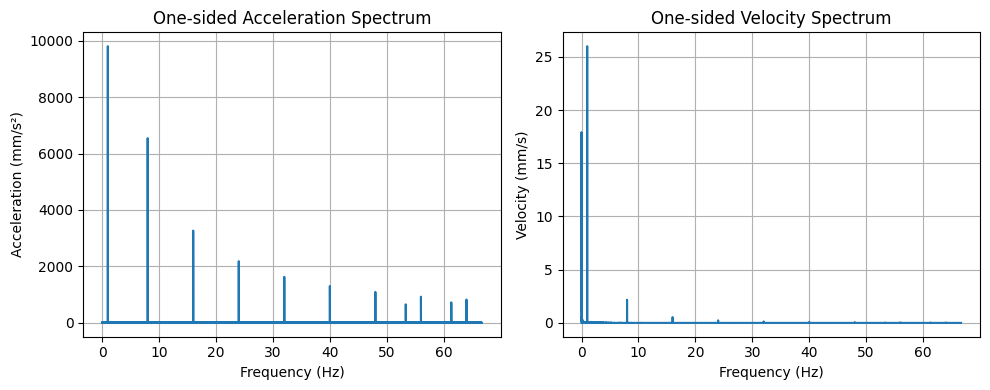

In [4]:
# Example usage
Fs = 8000  # Hz
T = 10.0 # seconds
N = int(Fs * T)  # Number of samples
t = np.linspace(0, T, N, endpoint=False)

# Example signal: 10 Hz sinusoidal acceleration at 0.5 g
A = GenerateVibrationData(N,Fs)

freqs, accel_spectrum, vel_spectrum = acceleration_to_velocity_fft(A, Fs)

freqs /= 60

# Plot results
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(freqs, accel_spectrum)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Acceleration (mm/s²)')
plt.title('One-sided Acceleration Spectrum')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(freqs, vel_spectrum)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Velocity (mm/s)')
plt.title('One-sided Velocity Spectrum')
plt.grid()

plt.tight_layout()
plt.show()


In [7]:
import plotly.express as px
acc = pd.DataFrame({'X (g)': A}, index=t)
acc_psd = endaq.calc.psd.welch(acc)
vel_psd = endaq.calc.psd.differentiate(acc_psd, n=-1)

# px.line(acc.head(1000))
px.line(vel_psd)

In [22]:
import yaml
import dearpygui.dearpygui as dpg

In [43]:
with open('../vibcheck_data_template.yaml','r') as f:
    tmpl = yaml.safe_load(f)
print(tmpl)

config = tmpl.copy()
guifields = dict()

def change_field(config, key, value):
    if isinstance(key, list):
        changefield(config[key[0]], key[1:], value)
    
    config[key] = value
def valuechange_callback(sender, app, something):
    print(sender)
    print(app)
    print(something)

dpg.create_context()
def add_field(key, value, path=tuple()):
    if isinstance(value, dict):
        dpg.add_text(key)
        for k, v in value.items():
            add_field(k,v, path + (key,))
        return
    
    dpg.add_input_text(label=key,default_value=value, callback=valuechange_callback)
    guifields[path] = dpg.last_item()

with dpg.window(label='CONFIG', height=800, width=800):
    dpg.add_text('dork')
    add_field('henry',tmpl)

dpg.create_viewport(title='Viewport', width=800, height=600)
dpg.setup_dearpygui()
dpg.show_viewport()
dpg.start_dearpygui()
dpg.destroy_context()

print(guifields)

{'date': None, 'customer': {'name': None, 'address': None, 'contact': None, 'CEO': None}, 'machine': {'name': None, 'serial': None, 'description': 'words\n', 'motor_info': {'running_rate': None}, 'bearing_info': None}, 'tests': {'time': None, 'fft': None, 'trend': None, 'ring': None}, 'processed_data': None}
48
s
None
48
sn
None
48
sno
None
48
snor
None
48
snork
None
48
snorkl
None
48
snorkle
None
{('henry',): 50, ('henry', 'customer'): 37, ('henry', 'machine'): 44, ('henry', 'machine', 'motor_info'): 43, ('henry', 'tests'): 49}


In [49]:
import time, threading
def targ(mesg,dt):
    for k in range(10):
        print(mesg, time.time())
        time.sleep(dt)

h = threading.Thread(target=lambda: targ('hello', 1))
w = threading.Thread(target=lambda: targ('world', 1.09))

h.start()
w.start()

h.join()
w.join()


In [112]:
df = pd.DataFrame(columns=['Time','X'])
for k in range(10):
    X = np.random.randint(10)
    df.loc[len(df)] = [ time.time(), X]
    time.sleep(X/10)

df

,Time,X
0,1.738814e+09,7.0
1,1.738814e+09,6.0
2,1.738814e+09,9.0
3,1.738814e+09,0.0
4,1.738814e+09,5.0
5,1.738814e+09,7.0
6,1.738814e+09,7.0
7,1.738814e+09,3.0
8,1.738814e+09,0.0
9,1.738814e+09,3.0


In [119]:
import endaq
bearing = pd.read_csv('https://info.endaq.com/hubfs/Plots/bearing_data.csv', index_col=0)
psd = endaq.calc.psd.welch(bearing, bin_width=1)
psd

,Fault_021,Fault_014,Fault_007,Normal
frequency (Hz),,,,
0.000000,6.257024e-08,7.088248e-10,1.115030e-09,3.899163e-08
1.000075,4.954885e-07,1.618520e-09,2.175011e-09,2.849303e-07
2.000150,3.030074e-07,3.620126e-10,4.010992e-10,1.299351e-07
3.000225,1.329539e-07,1.396026e-10,8.697872e-11,5.382347e-08
4.000300,7.933452e-08,1.038435e-10,7.841253e-11,3.248884e-08
...,...,...,...,...
5995.449662,1.046175e-07,4.292998e-08,3.235438e-07,5.883707e-13
5996.449737,1.761772e-07,7.895658e-08,4.513444e-07,8.132650e-13
5997.449812,2.844253e-07,6.373560e-08,9.356142e-08,6.269221e-13
